# loading data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database


# libs

In [2]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
#densenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input 

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")


2026-03-13 02:38:56.644205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773369536.827643      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773369536.878680      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773369537.337985      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773369537.338051      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773369537.338054      23 computation_placer.cc:177] computation placer alr

In [3]:
 folds = os.listdir(r'/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset')

In [4]:
folds

['Lung_Opacity.metadata.xlsx',
 'Normal.metadata.xlsx',
 'README.md.txt',
 'COVID.metadata.xlsx',
 'Normal',
 'Lung_Opacity',
 'Viral Pneumonia.metadata.xlsx',
 'Viral Pneumonia',
 'COVID']

In [5]:
foldpath = os.path.join("/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset", 'COVID.metadata.xlsx')

In [6]:
foldpath

'/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID.metadata.xlsx'

In [7]:
pathlib.Path(foldpath).suffix

'.xlsx'

In [8]:
# 1. Dataset Path and Structure
root_dir = '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset'
classes = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

print("--- Dataset Structure ---")
data_list = []

for cls in classes:
    # We target the 'images' folder and ignore 'masks'
    img_path = os.path.join(root_dir, cls, 'images')
    images = [os.path.join(img_path, f) for f in os.listdir(img_path) if f.endswith('.png')]
    print(f"Class: {cls} | Images: {len(images)}")
    
    for img in images:
        data_list.append([img, cls])

--- Dataset Structure ---
Class: COVID | Images: 3616
Class: Lung_Opacity | Images: 6012
Class: Normal | Images: 10192
Class: Viral Pneumonia | Images: 1345


In [9]:
# Create a DataFrame for easier handling
df = pd.DataFrame(data_list, columns=['image_path', 'label'])
# Map labels to integers
label_map = {cls: i for i, cls in enumerate(classes)}
df['label_idx'] = df['label'].map(label_map)

In [10]:
df['label'].unique()

array(['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia'], dtype=object)

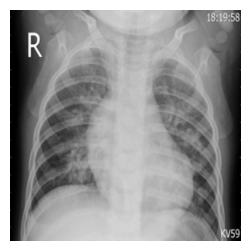

(299, 299)


In [11]:
image=plt.imread(img)

plt.figure(figsize=(10, 3))
plt.imshow(image,cmap='gray')
plt.axis('off')
plt.show()
print(image.shape)

In [12]:
def define_paths(data_dir):
    filepaths = []
    labels = []

    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        # check the folders from main directory. If there are another files, ignore them
        if pathlib.Path(foldpath).suffix != '':
            continue

        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)

            # check if there are another folders
            if pathlib.Path(foldpath).suffix == '':
                # check unneeded masks
                if pathlib.Path(fpath).parts[-1] == 'masks' or pathlib.Path(fpath).parts[-1] == 'Masks' or pathlib.Path(fpath).parts[-1] == 'MASKS':
                    continue

                else:
                    o_file = os.listdir(fpath)
                    for f in o_file:
                        ipath = os.path.join(fpath, f)
                        filepaths.append(ipath)
                        labels.append(fold)

            else:            
                filepaths.append(fpath)
                labels.append(fold)

    return filepaths, labels


# Concatenate data paths with labels into one dataframe ( to later be fitted into the model )
def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

# Split dataframe to train, valid, and test
def split_data(data_dir):
    # train dataframe
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df['labels']
    train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

    # valid and test dataframe
    strat = dummy_df['labels']
    valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

    return train_df, valid_df, test_df

In [13]:


def create_gens(train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframes and fits them into image data generators.
    Adjusted specifically for Chest X-Ray images and DenseNet architecture.
    '''
    # define model parameters
    img_size = (224, 224)
    channels = 3 
    color = 'rgb'

    # Custom function for test data batch size
    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    
    # 1 Augmentation 
    tr_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input, 
        rotation_range=10,                       
        zoom_range=0.1,                          
        fill_mode='nearest'                      
        
    )
    
    
    ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

    
    train_gen = tr_gen.flow_from_dataframe(
        train_df, x_col='filepaths', y_col='labels', 
        target_size=img_size, class_mode='categorical',
        color_mode=color, shuffle=True, batch_size=batch_size
    )

    valid_gen = ts_gen.flow_from_dataframe(
        valid_df, x_col='filepaths', y_col='labels', 
        target_size=img_size, class_mode='categorical',
        color_mode=color, shuffle=True, batch_size=batch_size
    )

    test_gen = ts_gen.flow_from_dataframe(
        test_df, x_col='filepaths', y_col='labels', 
        target_size=img_size, class_mode='categorical',
        color_mode=color, shuffle=False, batch_size=test_batch_size
    )

    return train_gen, valid_gen, test_gen

In [14]:
def show_images(gen):
    '''
    This function takes the data generator and shows a sample of the images.
    Fixed for DenseNet preprocessed inputs.
    '''
    
    g_dict = gen.class_indices        
    classes = list(g_dict.keys())     
    images, labels = next(gen)       

    # 2. تحديد عدد الصور اللي هتتعرض (أقصى حاجة 25)
    length = len(labels)        
    sample = min(length, 25)    

    plt.figure(figsize=(15, 15)) # صغرنا الحجم شوية عشان تظهر كاملة 

    
    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        
        #  هنحجم الأرقام بين 0 و 1 بدل ما نقسم على 255
        image = np.clip(images[i], 0, 1) 
        
        plt.imshow(image)
        index = np.argmax(labels[i])  
        class_name = classes[index]   
        
        
        title_color = 'green' if class_name.lower() == 'normal' else 'red'
        
        plt.title(class_name, color=title_color, fontsize=12, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()



In [15]:
data_dir = '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset'

try:
    # Get splitted data
    train_df, valid_df, test_df = split_data(data_dir)

    # Get Generators
    batch_size = 16
    train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)

except:
    print('Invalid Input')

Found 16932 validated image filenames belonging to 4 classes.
Found 2116 validated image filenames belonging to 4 classes.
Found 2117 validated image filenames belonging to 4 classes.


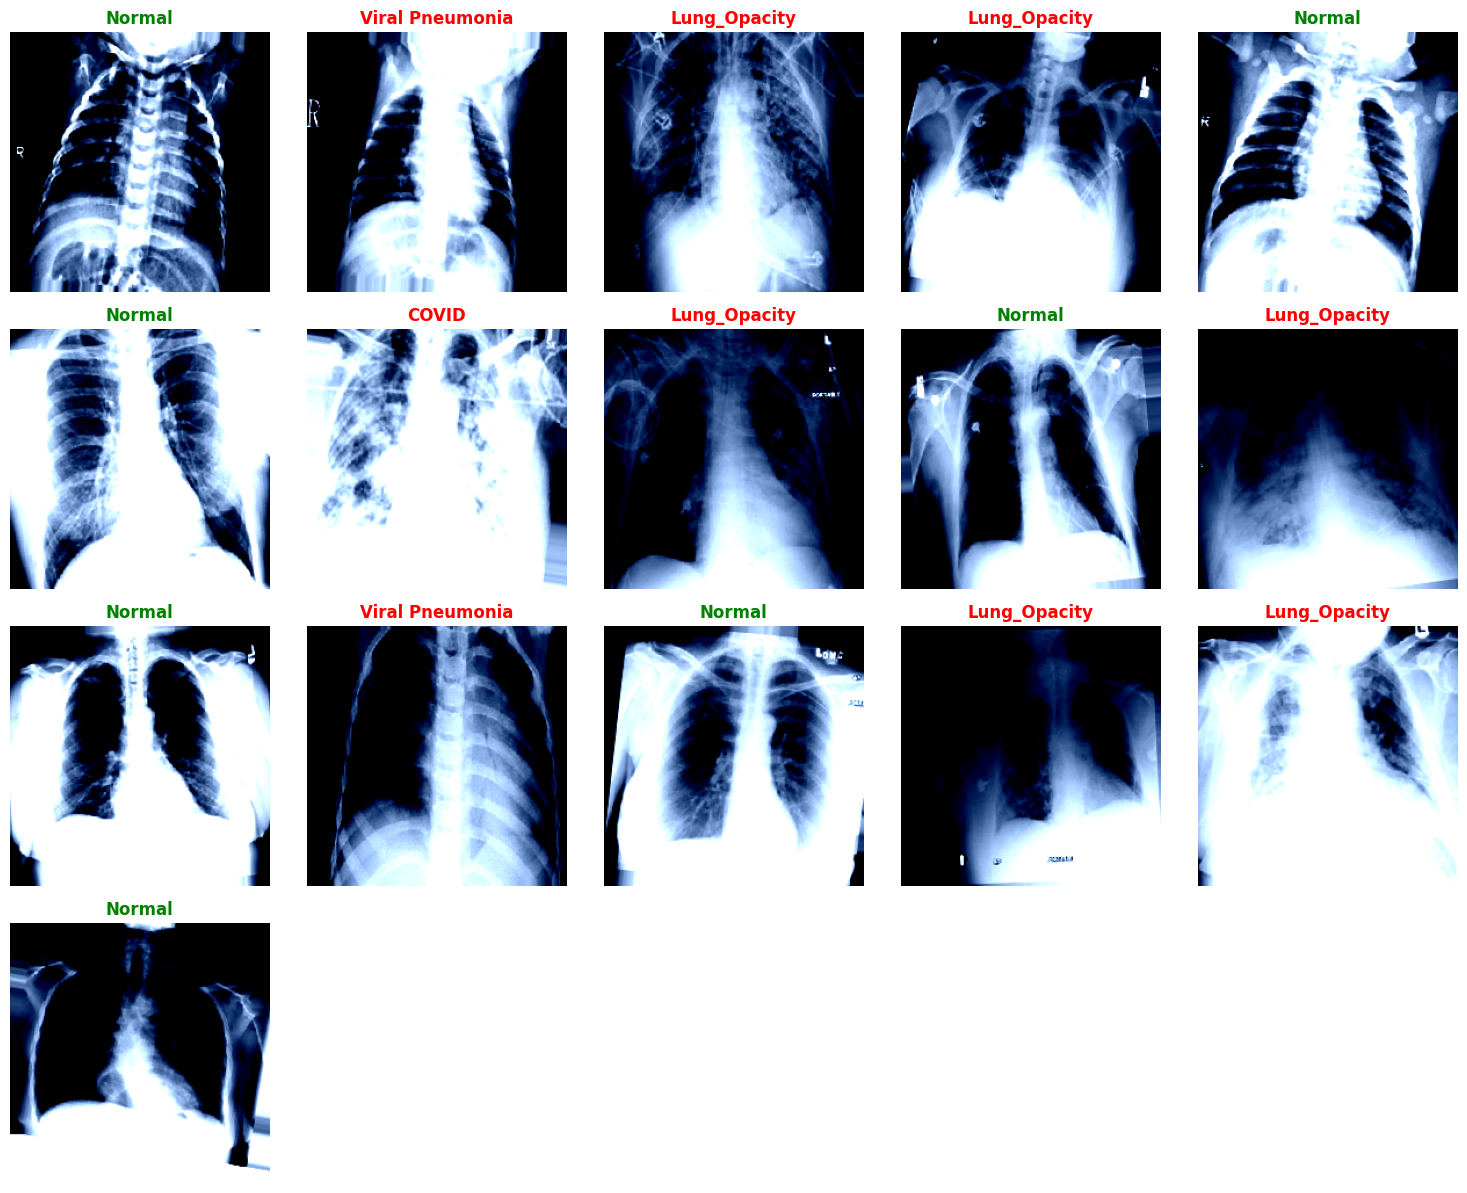

In [16]:
show_images(train_gen)

In [17]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) 


base_model = tf.keras.applications.DenseNet121(
    include_top=False, 
    weights="imagenet", 
    input_shape=img_shape, 
    pooling='max'
)
base_model.trainable = False # Freeze 

# Build the Sequential model
model = Sequential([
    base_model,
    Dropout(0.4), 
    Dense(class_count, activation='softmax')
])

# Compile the model
model.compile(
    optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.0001,
    weight_decay=1e-5
), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1773369612.910494      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [18]:
callbacks = [
    
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    
    
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3)
]

In [19]:
history = model.fit(x= train_gen, epochs= 50, callbacks= callbacks,
                    validation_data= valid_gen, shuffle= False)

Epoch 1/50


I0000 00:00:1773369630.424665      69 service.cc:152] XLA service 0x7af274004740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773369630.424706      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773369633.620230      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1059 ━━━━━━━━━━━━━━━━━━━━ 7:26:38 25s/step - accuracy: 0.3125 - loss: 4.7581

I0000 00:00:1773369644.369165      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1059/1059 ━━━━━━━━━━━━━━━━━━━━ 348s 305ms/step - accuracy: 0.4142 - loss: 3.3701 - val_accuracy: 0.6905 - val_loss: 1.0456 - learning_rate: 1.0000e-04
Epoch 2/50
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 209s 197ms/step - accuracy: 0.5591 - loss: 1.9256 - val_accuracy: 0.7524 - val_loss: 0.7855 - learning_rate: 1.0000e-04
Epoch 3/50
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 205s 194ms/step - accuracy: 0.6333 - loss: 1.3838 - val_accuracy: 0.7836 - val_loss: 0.6416 - learning_rate: 1.0000e-04
Epoch 4/50
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 203s 192ms/step - accuracy: 0.6727 - loss: 1.0962 - val_accuracy: 0.7958 - val_loss: 0.6187 - learning_rate: 1.0000e-04
Epoch 5/50
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 204s 192ms/step - accuracy: 0.6915 - loss: 0.9321 - val_accuracy: 0.7958 - val_loss: 0.5697 - learning_rate: 1.0000e-04
Epoch 6/50
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 205s 194ms/step - accuracy: 0.7138 - loss: 0.8184 - val_accuracy: 0.8025 - val_loss: 0.5267 - learning_rate: 1.0000e-04
Epoch 7/50
1059/1059 ━━━━━━━━━━━━━━━━━━

In [20]:
history


In [21]:
history.history

{'accuracy': [0.4586581587791443,
  0.5841010808944702,
  0.6467635035514832,
  0.6847389340400696,
  0.6992676854133606,
  0.7192889451980591,
  0.7356484532356262,
  0.7452161312103271,
  0.7512993216514587,
  0.7588589787483215,
  0.7586227059364319,
  0.7639381289482117,
  0.7609851360321045,
  0.7655327320098877,
  0.7628750205039978,
  0.7602763772010803],
 'loss': [2.866204261779785,
  1.727187991142273,
  1.288405179977417,
  1.027689814567566,
  0.8894394636154175,
  0.7904108166694641,
  0.7103843092918396,
  0.6720148324966431,
  0.6546472907066345,
  0.6342380046844482,
  0.6355478167533875,
  0.6224406957626343,
  0.6187506914138794,
  0.615494966506958,
  0.6135343313217163,
  0.616981565952301],
 'val_accuracy': [0.6904537081718445,
  0.7523629665374756,
  0.7835538983345032,
  0.7958412170410156,
  0.7958412170410156,
  0.8024574518203735,
  0.8123818635940552,
  0.7911152839660645,
  0.793005645275116,
  0.8133270144462585,
  0.818525493144989,
  0.8067107796669006,
  

29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 734ms/step - accuracy: 0.8311 - loss: 0.4661
------------------------------
test_acc=83.23%
test_loss= 0.4677
------------------------------


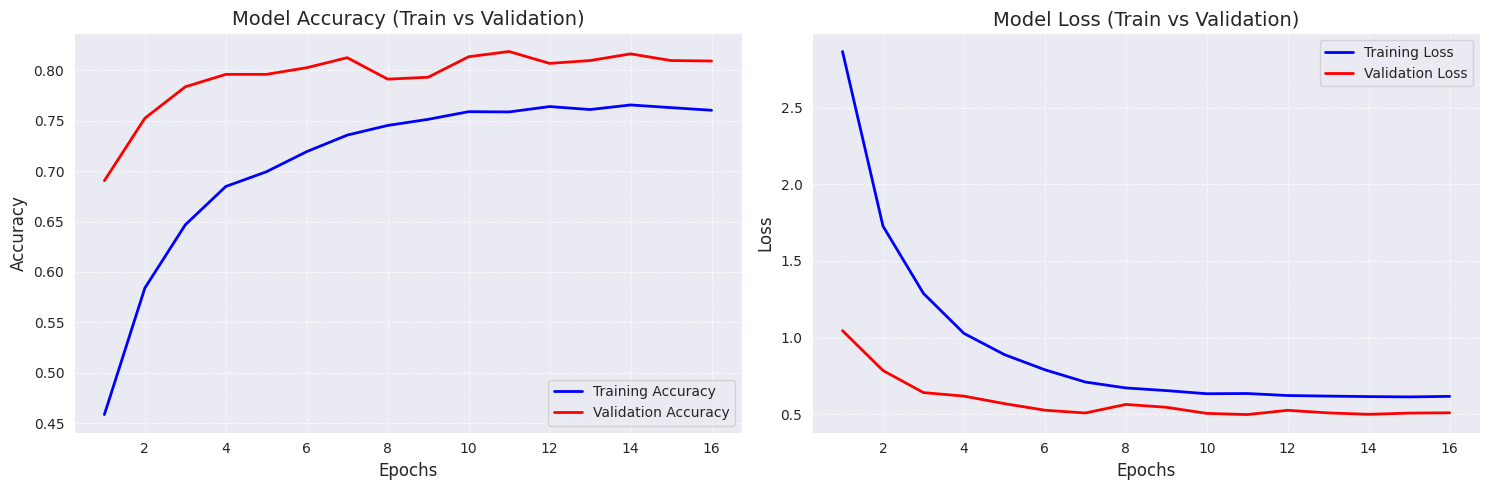

In [22]:
test_loss, test_acc = model.evaluate(test_gen)
print("-" * 30)
print(f"test_acc={test_acc * 100:.2f}%")
print(f"test_loss= {test_loss:.4f}")
print("-" * 30)



tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = range(1, len(tr_acc) + 1)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, tr_acc, 'b', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy (Train vs Validation)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, tr_loss, 'b', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r', label='Validation Loss', linewidth=2)
plt.title('Model Loss (Train vs Validation)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# Fine tuning

In [23]:
b=list(base_model.layers)

In [24]:
b[0]

<InputLayer name=input_layer, built=True>

In [25]:
len(b)

428

In [26]:
base_model.trainable = True

In [27]:
fine_tune_at = 300

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'{fine_tune_at} layers closed')

300 layers closed


In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=1e-5), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)


In [29]:

callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5)
]

In [30]:
history_finetune = model.fit(
    x=train_gen, 
    epochs=10, 
    validation_data=valid_gen, 
    callbacks=callbacks_finetune,
    shuffle=False
)

Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 332s 265ms/step - accuracy: 0.5756 - loss: 1.3340 - val_accuracy: 0.8095 - val_loss: 0.5399 - learning_rate: 1.0000e-05
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 208s 196ms/step - accuracy: 0.7148 - loss: 0.8335 - val_accuracy: 0.8233 - val_loss: 0.5019 - learning_rate: 1.0000e-05
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 206s 194ms/step - accuracy: 0.7417 - loss: 0.7642 - val_accuracy: 0.8322 - val_loss: 0.4765 - learning_rate: 1.0000e-05
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 212s 200ms/step - accuracy: 0.7628 - loss: 0.6998 - val_accuracy: 0.8417 - val_loss: 0.4566 - learning_rate: 1.0000e-05
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 210s 199ms/step - accuracy: 0.7730 - loss: 0.6827 - val_accuracy: 0.8507 - val_loss: 0.4264 - learning_rate: 1.0000e-05
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 207s 196ms/step - accuracy: 0.7946 - loss: 0.6084 - val_accuracy: 0.8559 - val_loss: 0.4077 - learning_rate: 1.0000e-05
Epoch 7/10
1059/1059 ━━━━━━━

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 372ms/step - accuracy: 0.8908 - loss: 0.3185
------------------------------
test_acc=89.14%
test_loss= 0.3087
------------------------------


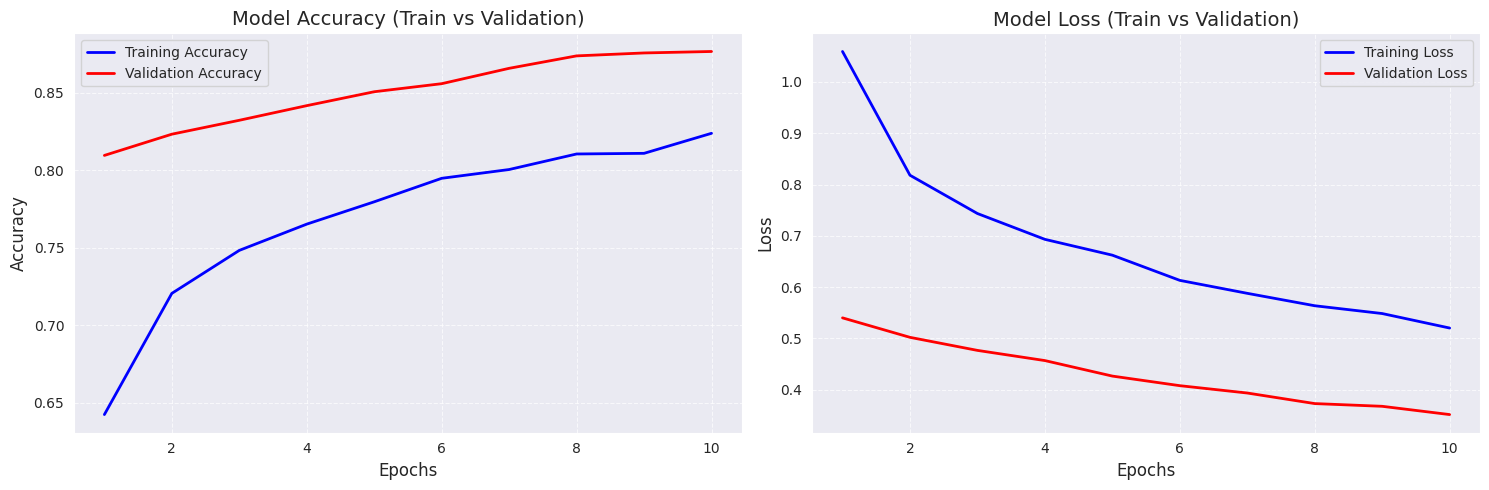

In [31]:
test_loss, test_acc = model.evaluate(test_gen)
print("-" * 30)
print(f"test_acc={test_acc * 100:.2f}%")
print(f"test_loss= {test_loss:.4f}")
print("-" * 30)



tr_acc = history_finetune.history['accuracy']
tr_loss = history_finetune.history['loss']
val_acc = history_finetune.history['val_accuracy']
val_loss = history_finetune.history['val_loss']

epochs = range(1, len(tr_acc) + 1)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, tr_acc, 'b', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy (Train vs Validation)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, tr_loss, 'b', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r', label='Validation Loss', linewidth=2)
plt.title('Model Loss (Train vs Validation)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):
	'''
	This function plot confusion matrix method from sklearn package.
	'''

	plt.figure(figsize= (10, 10))
	plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
	plt.title(title)
	plt.colorbar()

	tick_marks = np.arange(len(classes))
	plt.xticks(tick_marks, classes, rotation= 45)
	plt.yticks(tick_marks, classes)

	if normalize:
		cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
		print('Normalized Confusion Matrix')

	else:
		print('Confusion Matrix, Without Normalization')

	print(cm)

	thresh = cm.max() / 2.
	for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
		plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

	plt.tight_layout()
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')

# Deeper Fine-Tuning

In [33]:
from sklearn.utils.class_weight import compute_class_weight



train_classes = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
#حولتها ل ديكشنري عشان keras يفهمها
class_weights_dict = dict(enumerate(class_weights))
print(f"الأوزان : {class_weights_dict}")


base_model.trainable = True


fine_tune_at = 200 

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=5e-6), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)


callbacks_ultra = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5)
]

print(" (The Final Push)...")

history_ultra = model.fit(
    x=train_gen, 
    epochs=15, 
    validation_data=valid_gen, 
    callbacks=callbacks_ultra,
    class_weight=class_weights_dict,  
    shuffle=False
)

الأوزان : {0: np.float64(1.4631870031109575), 1: np.float64(0.8802245789145352), 2: np.float64(0.5191317144959529), 3: np.float64(3.934014869888476)}
 (The Final Push)...
Epoch 1/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 343s 273ms/step - accuracy: 0.8150 - loss: 0.5475 - val_accuracy: 0.8800 - val_loss: 0.3251 - learning_rate: 5.0000e-06
Epoch 2/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 214s 202ms/step - accuracy: 0.8053 - loss: 0.4829 - val_accuracy: 0.8804 - val_loss: 0.3236 - learning_rate: 5.0000e-06
Epoch 3/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 210s 198ms/step - accuracy: 0.8043 - loss: 0.5031 - val_accuracy: 0.8804 - val_loss: 0.3246 - learning_rate: 5.0000e-06
Epoch 4/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 222s 210ms/step - accuracy: 0.8119 - loss: 0.4652 - val_accuracy: 0.8809 - val_loss: 0.3205 - learning_rate: 5.0000e-06
Epoch 5/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 219s 207ms/step - accuracy: 0.8125 - loss: 0.4649 - val_accuracy: 0.8809 - val_loss: 0.3186 - learning_rate: 5.0000e-06
Epoch 6/15
1059/105

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 347ms/step - accuracy: 0.8997 - loss: 0.2752
------------------------------
test_acc=90.65%
test_loss= 0.2663
------------------------------


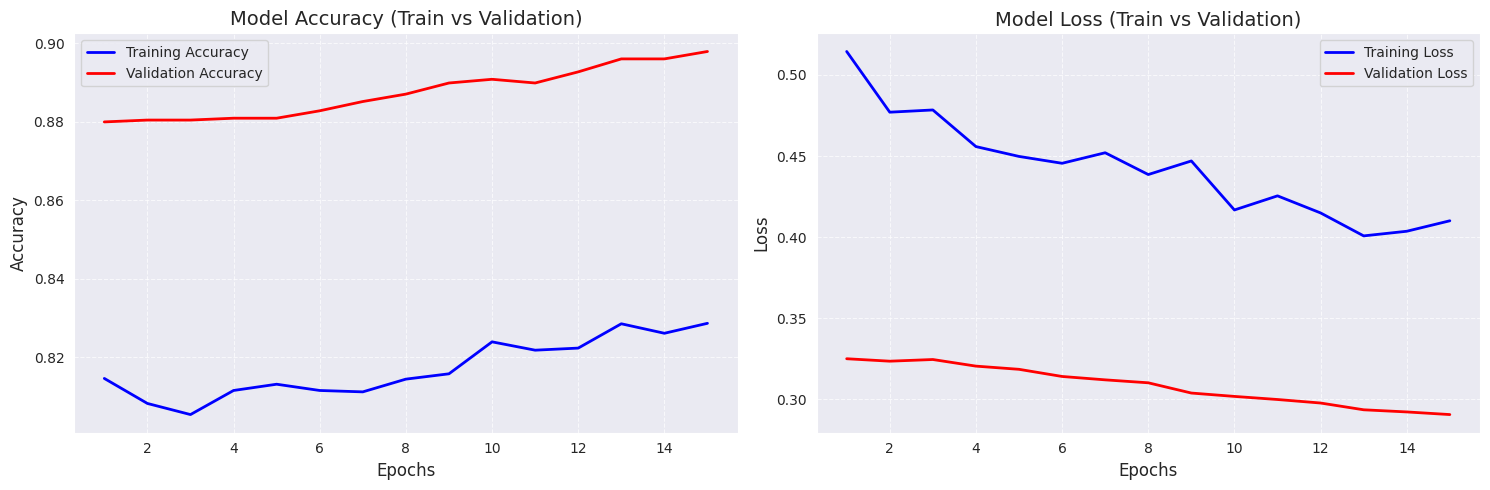

In [34]:
test_loss, test_acc = model.evaluate(test_gen)
print("-" * 30)
print(f"test_acc={test_acc * 100:.2f}%")
print(f"test_loss= {test_loss:.4f}")
print("-" * 30)



tr_acc = history_ultra.history['accuracy']
tr_loss = history_ultra.history['loss']
val_acc = history_ultra.history['val_accuracy']
val_loss = history_ultra.history['val_loss']

epochs = range(1, len(tr_acc) + 1)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, tr_acc, 'b', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy (Train vs Validation)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, tr_loss, 'b', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r', label='Validation Loss', linewidth=2)
plt.title('Model Loss (Train vs Validation)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.9074 - loss: 0.2753
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8773 - loss: 0.3924
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - accuracy: 0.8997 - loss: 0.2752
Train Loss:  0.27382752299308777
Train Accuracy:  0.9094827771186829
--------------------
Validation Loss:  0.32266637682914734
Validation Accuracy:  0.892241358757019
--------------------
Test Loss:  0.2662835717201233
Test Accuracy:  0.9064714312553406


In [36]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
print(y_pred)

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step
[1 1 0 ... 2 2 1]


Confusion Matrix, Without Normalization
[[320   9  32   1]
 [ 25 529  48   0]
 [ 22  43 936  18]
 [  0   0   0 134]]
                 precision    recall  f1-score   support

          COVID       0.87      0.88      0.88       362
   Lung_Opacity       0.91      0.88      0.89       602
         Normal       0.92      0.92      0.92      1019
Viral Pneumonia       0.88      1.00      0.93       134

       accuracy                           0.91      2117
      macro avg       0.89      0.92      0.91      2117
   weighted avg       0.91      0.91      0.91      2117



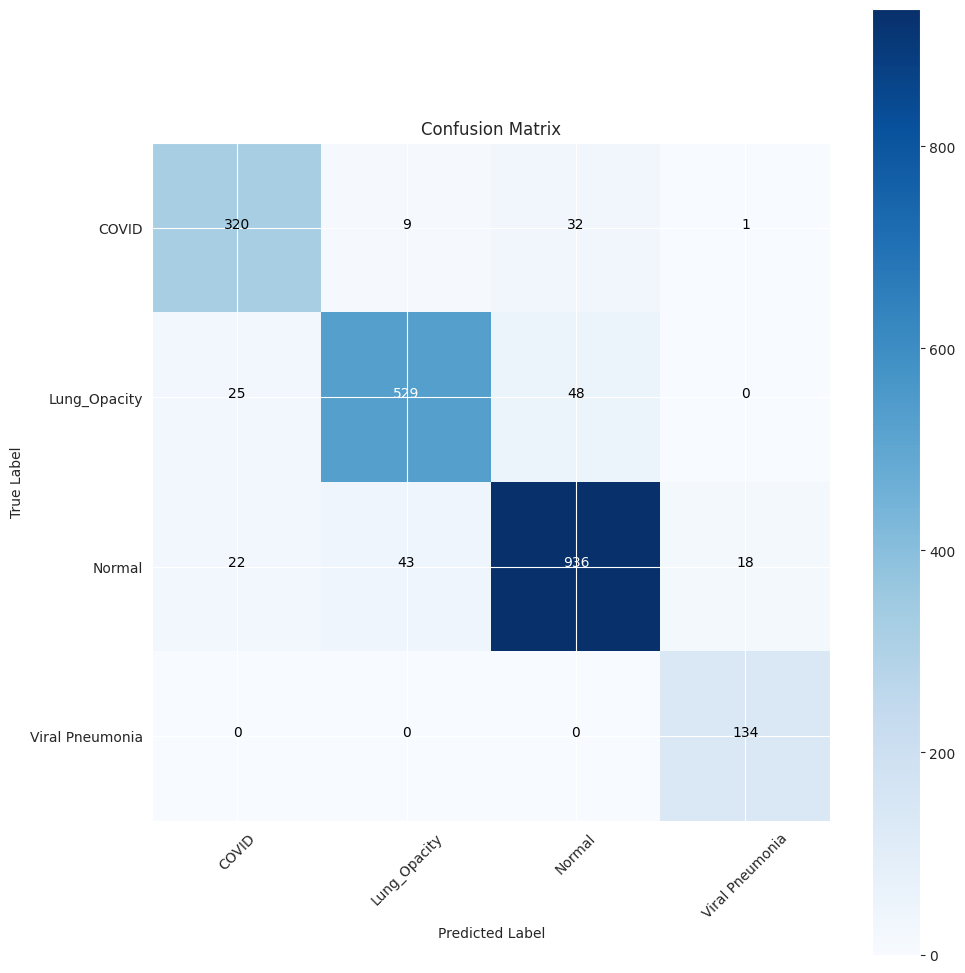

In [37]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm= cm, classes= classes, title = 'Confusion Matrix')

# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

In [38]:
model.save('model.keras')
print("saved")

saved
